# Laboratorio 10: ETL, EDA y Feature Engineering - Titanic Dataset

Bienvenido a este laboratorio avanzado de análisis de datos. En esta sesión, exploraremos el legendario dataset del Titanic para entender qué factores influyeron en la supervivencia de los pasajeros. Pasaremos por un flujo completo de Ciencia de Datos: desde la extracción de datos (ETL) y el análisis exploratorio (EDA) hasta una ingeniería de características (Feature Engineering) detallada, preparando la información para futuros modelos de aprendizaje automático.

## 📋 Tabla de Contenidos

1. [Configuración Inicial e Imports](#-imports)
2. [ETL: Extracción, Transformación y Carga](#-etl)
3. [EDA: Análisis Exploratorio de Datos](#-eda)
4. [Feature Engineering: Ingeniería de Características](#-feature-engineering)
5. [Preprocesamiento con Scikit-Learn](#-sklearn)

---

<a id='-imports'></a>
## 🔹 1: Configuración Inicial e Imports

En esta sección preparamos el entorno de trabajo importando las librerías necesarias para el manejo de datos, visualización y preprocesamiento. Configuramos los parámetros globales para garantizar gráficos consistentes y profesionales.

In [1]:
#!pip install jupyter-black
%load_ext jupyter_black

In [2]:
import warnings
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pylab as plot
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)

%matplotlib inline

# Configuración de visualización para Pandas
pd.options.display.max_columns = 100

# Parámetros de graficación
params = {
    "axes.labelsize": "large",
    "xtick.labelsize": "x-large",
    "legend.fontsize": 20,
    "figure.dpi": 150,
    "figure.figsize": [25, 7],
}
plot.rcParams.update(params)

---

<a id='-etl'></a>
## 🔹 2: ETL (Extracción, Transformación y Carga)

El primer paso consiste en cargar el conjunto de datos y realizar un diagnóstico inicial de su estructura, tipos de datos y calidad de la información (valores faltantes).

### 📝 2.1 Carga de Datos

Cargamos el archivo CSV que contiene los datos de entrenamiento del Titanic.

In [3]:
# Cargar el training set
data = pd.read_csv("train.csv")

### 📝 2.2 Información Inicial del Dataset

Utilizamos métodos fundamentales de Pandas para obtener una visión general de la arquitectura de los datos.

In [4]:
# Resumen técnico de las columnas y tipos de datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Muestra aleatoria para validación
print("\nMuestra aleatoria de 5 registros:")
data.sample(5)


Muestra aleatoria de 5 registros:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
701,702,1,1,"Silverthorne, Mr. Spencer Victor",male,35.0,0,0,PC 17475,26.2875,E24,S
107,108,1,3,"Moss, Mr. Albert Johan",male,NaN,0,0,312991,7.7750,NaN,S
574,575,0,3,"Rush, Mr. Alfred George John",male,16.0,0,0,A/4. 20589,8.0500,NaN,S
175,176,0,3,"Klasen, Mr. Klas Albin",male,18.0,1,1,350404,7.8542,NaN,S
280,281,0,3,"Duane, Mr. Frank",male,65.0,0,0,336439,7.7500,NaN,Q


In [6]:
# Estadísticas descriptivas generales
print("\nResumen estadístico de variables numéricas:")
data.describe()


Resumen estadístico de variables numéricas:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


---

<a id='-eda'></a>
## 🔹 3: Análisis Exploratorio de Datos (EDA)

En esta fase, generamos visualizaciones para validar hipótesis y encontrar correlaciones clave entre las variables y la supervivencia de los pasajeros.

### 📝 3.1 Conteo de Sobrevivientes vs Fallecidos por Género

Evaluamos la proporción de supervivencia segmentada por el género del pasajero.

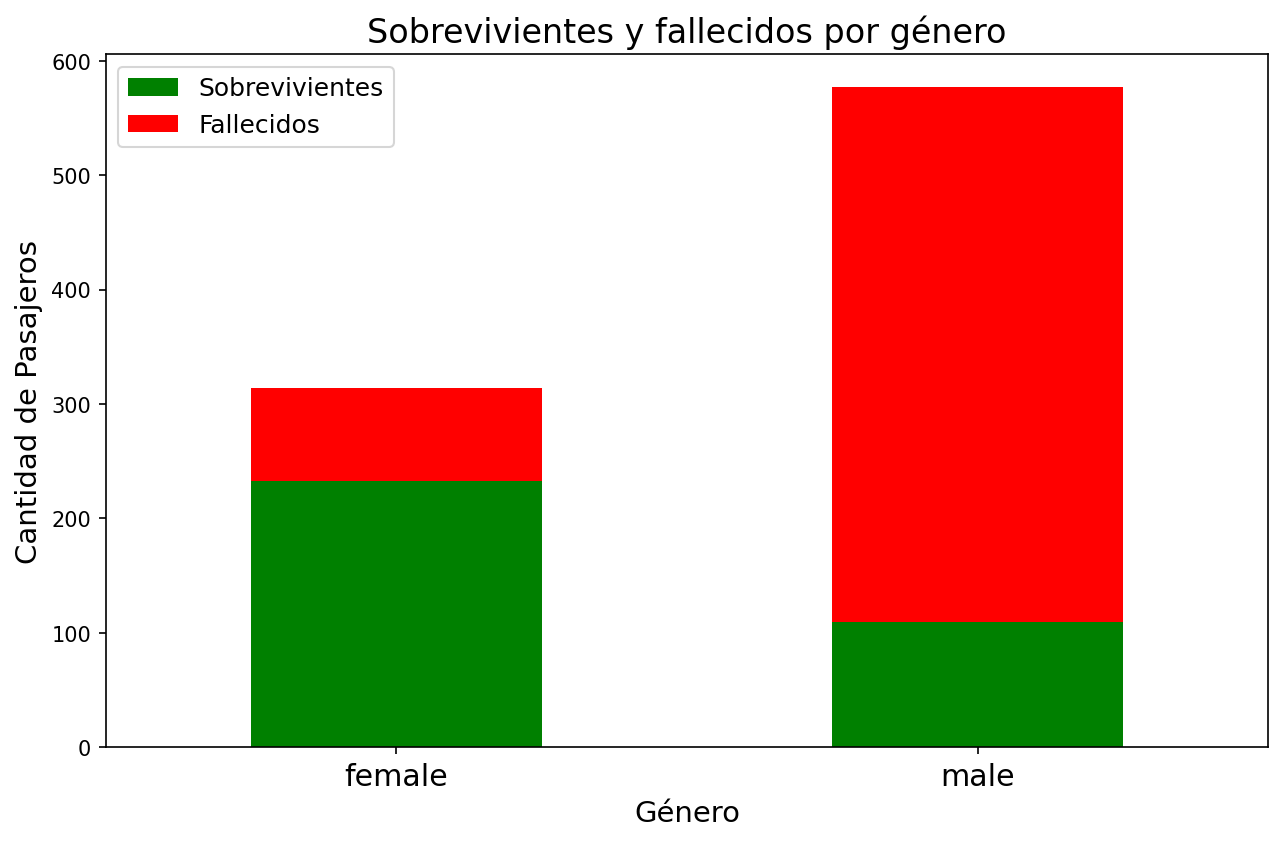

In [7]:
# Cálculo de fallecidos
data["Died"] = 1 - data["Survived"]

# Agrupación por género y supervivencia
survival_by_gender = data.groupby("Sex").agg("sum")[["Survived", "Died"]]

# Ploteo de barras apiladas
survival_by_gender.plot(kind="bar", stacked=True, color=["g", "r"], figsize=(10, 6))

plt.title("Sobrevivientes y fallecidos por género", fontsize=16)
plt.xlabel("Género", fontsize=14)
plt.ylabel("Cantidad de Pasajeros", fontsize=14)
plt.xticks(rotation=0)
plt.legend(["Sobrevivientes", "Fallecidos"], fontsize=12)

plt.show()

> **Interpretación:** Las mujeres muestran una tasa de supervivencia significativamente mayor que los hombres, lo que sugiere una prioridad en el rescate basada en el género.

### 📝 3.2 Distribución de Edades por Género y Supervivencia

Analizamos la distribución de edad utilizando un gráfico de violín para observar la densidad de sobrevivientes por rangos etarios.

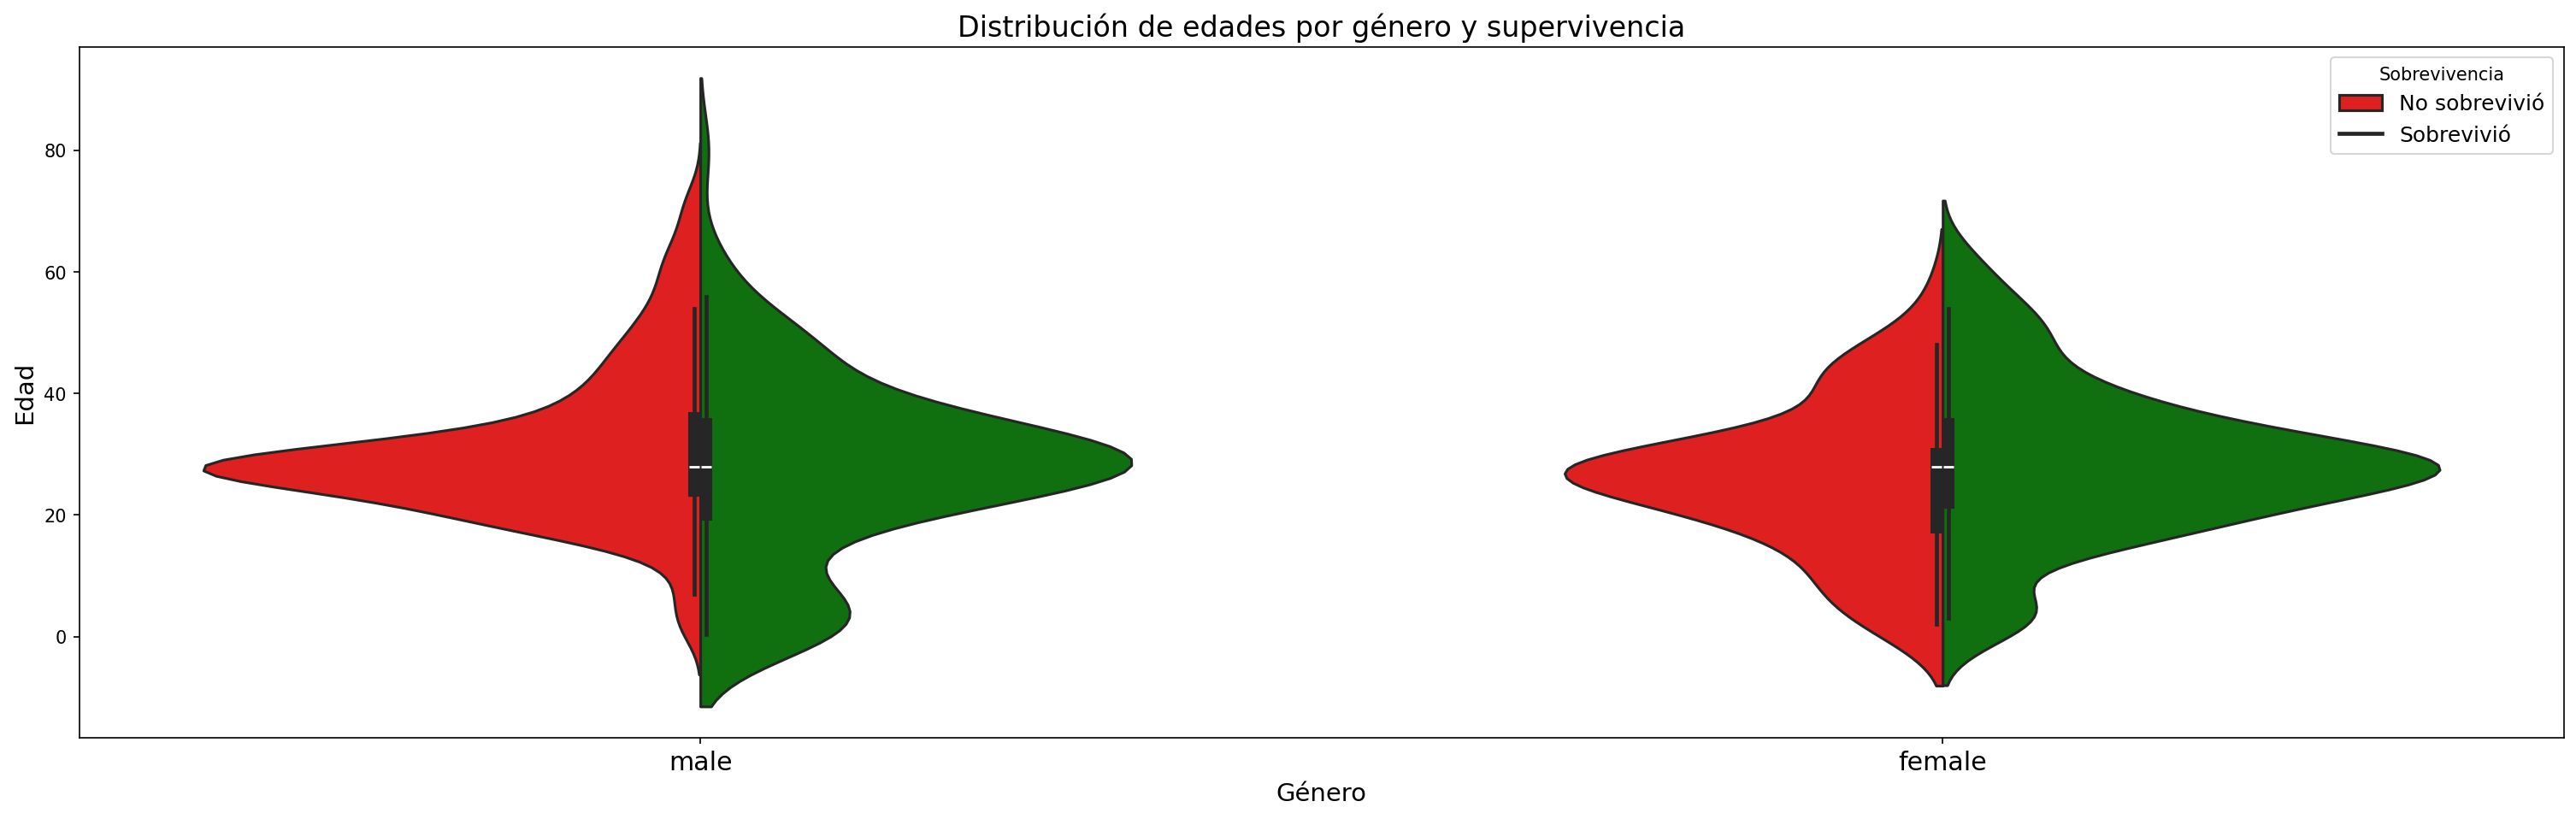

In [8]:
# Imputación temporal para visualización
data["Age"] = data["Age"].fillna(data["Age"].median())

plt.figure(figsize=(25, 7))
sns.violinplot(
    x="Sex",
    y="Age",
    hue="Survived",
    data=data,
    split=True,
    palette={0: "r", 1: "g"},
    linewidth=1.5,
)

plt.title("Distribución de edades por género y supervivencia", fontsize=16)
plt.xlabel("Género", fontsize=14)
plt.ylabel("Edad", fontsize=14)
plt.legend(
    title="Sobrevivencia",
    loc="upper right",
    labels=["No sobrevivió", "Sobrevivió"],
    fontsize=12,
)

plt.show()

> **Interpretación:** En los hombres, la edad es un factor determinante: los más jóvenes tuvieron mayor probabilidad de sobrevivir. En las mujeres, la edad no parece impactar de forma tan directa en la supervivencia.

### 📝 3.3 Distribución de Tarifas por Supervivencia

Determinamos si el precio del pasaje (correlacionado con el estatus social) influyó en el rescate.

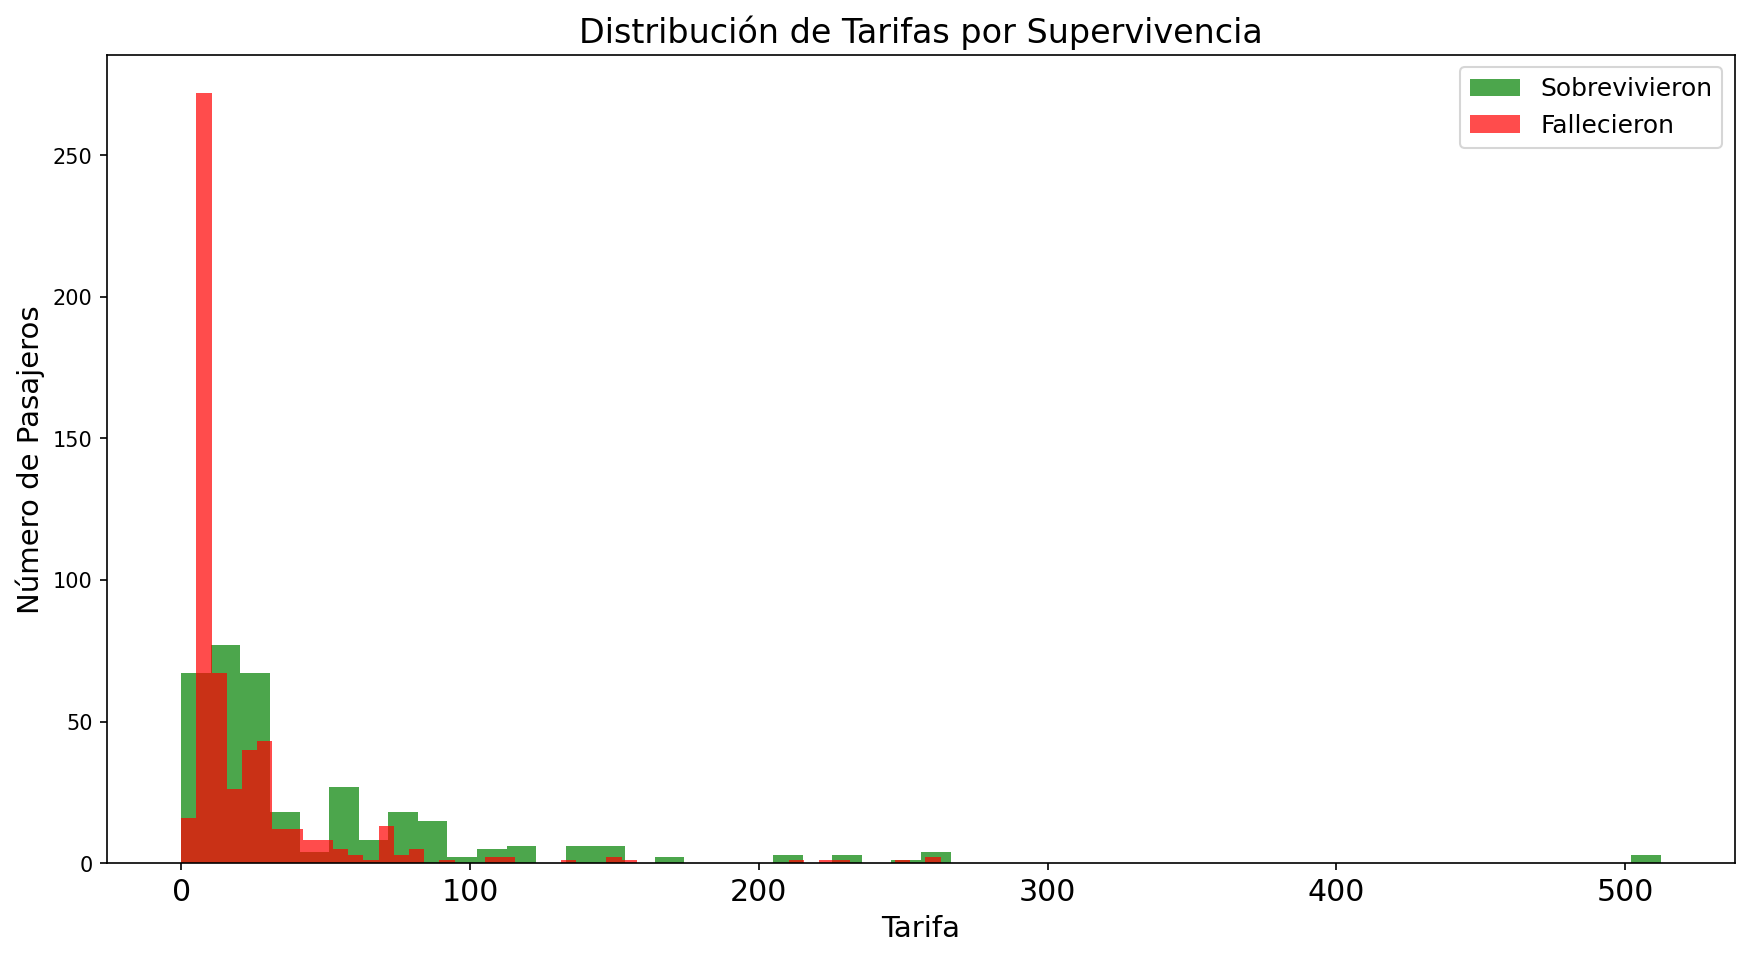

In [9]:
fig, ax = plt.subplots(figsize=(14, 7))

# Histogramas superpuestos
ax.hist(
    data[data["Survived"] == 1]["Fare"],
    bins=50,
    color="g",
    alpha=0.7,
    label="Sobrevivieron",
)
ax.hist(
    data[data["Survived"] == 0]["Fare"],
    bins=50,
    color="r",
    alpha=0.7,
    label="Fallecieron",
)

ax.set_xlabel("Tarifa", fontsize=14)
ax.set_ylabel("Número de Pasajeros", fontsize=14)
ax.set_title("Distribución de Tarifas por Supervivencia", fontsize=16)
ax.legend(loc="upper right", fontsize=12)

plt.show()

> **Interpretación:** Existe una clara tendencia donde los pasajeros con tarifas más bajas tuvieron menos probabilidades de sobrevivir, evidenciando una brecha de clase en el salvamento.

### 📝 3.4 Relación entre Edad, Tarifa y Supervivencia

Utilizamos un gráfico de dispersión para integrar tres dimensiones de análisis y observar patrones multivariados.

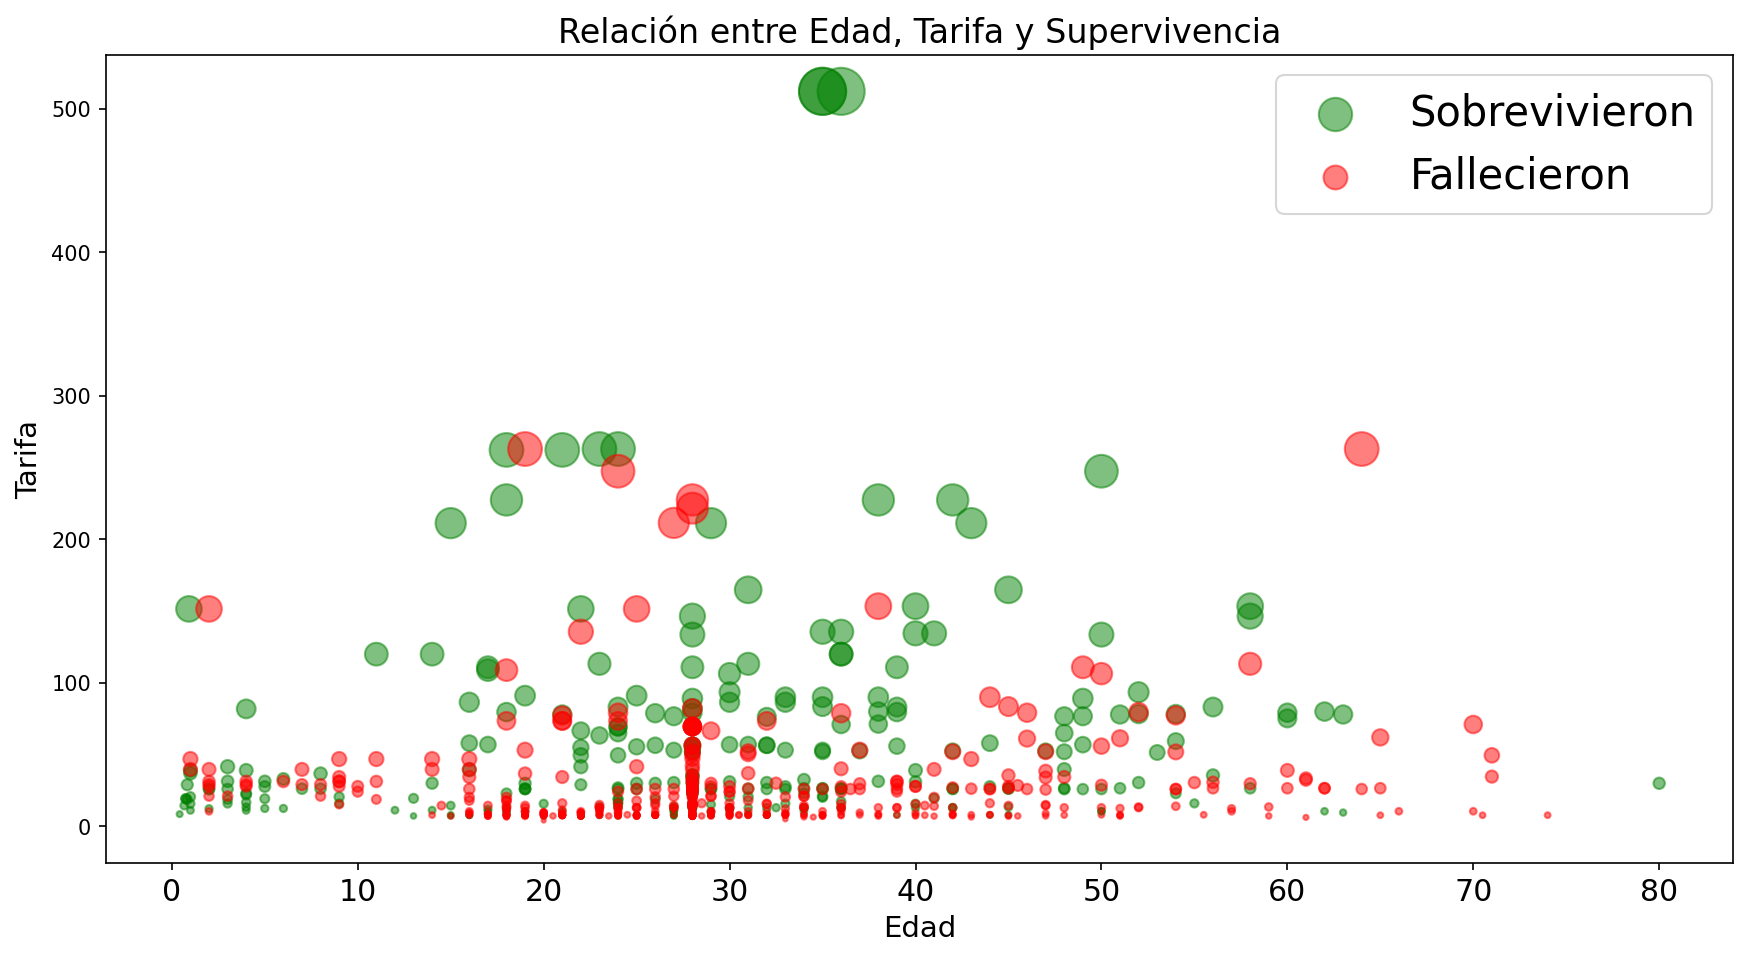

In [10]:
plt.figure(figsize=(14, 7))
ax = plt.subplot()

ax.scatter(
    data[data["Survived"] == 1]["Age"],
    data[data["Survived"] == 1]["Fare"],
    c="green",
    s=data[data["Survived"] == 1]["Fare"],
    label="Sobrevivieron",
    alpha=0.5,
)

ax.scatter(
    data[data["Survived"] == 0]["Age"],
    data[data["Survived"] == 0]["Fare"],
    c="red",
    s=data[data["Survived"] == 0]["Fare"],
    label="Fallecieron",
    alpha=0.5,
)

ax.set_xlabel("Edad", fontsize=14)
ax.set_ylabel("Tarifa", fontsize=14)
ax.set_title("Relación entre Edad, Tarifa y Supervivencia", fontsize=16)
ax.legend()

plt.show()

### 📝 3.5 Tarifa Promedio por Clase (Pclass)

Confirmamos la relación entre la variable categórica Pclass y el costo del pasaje.

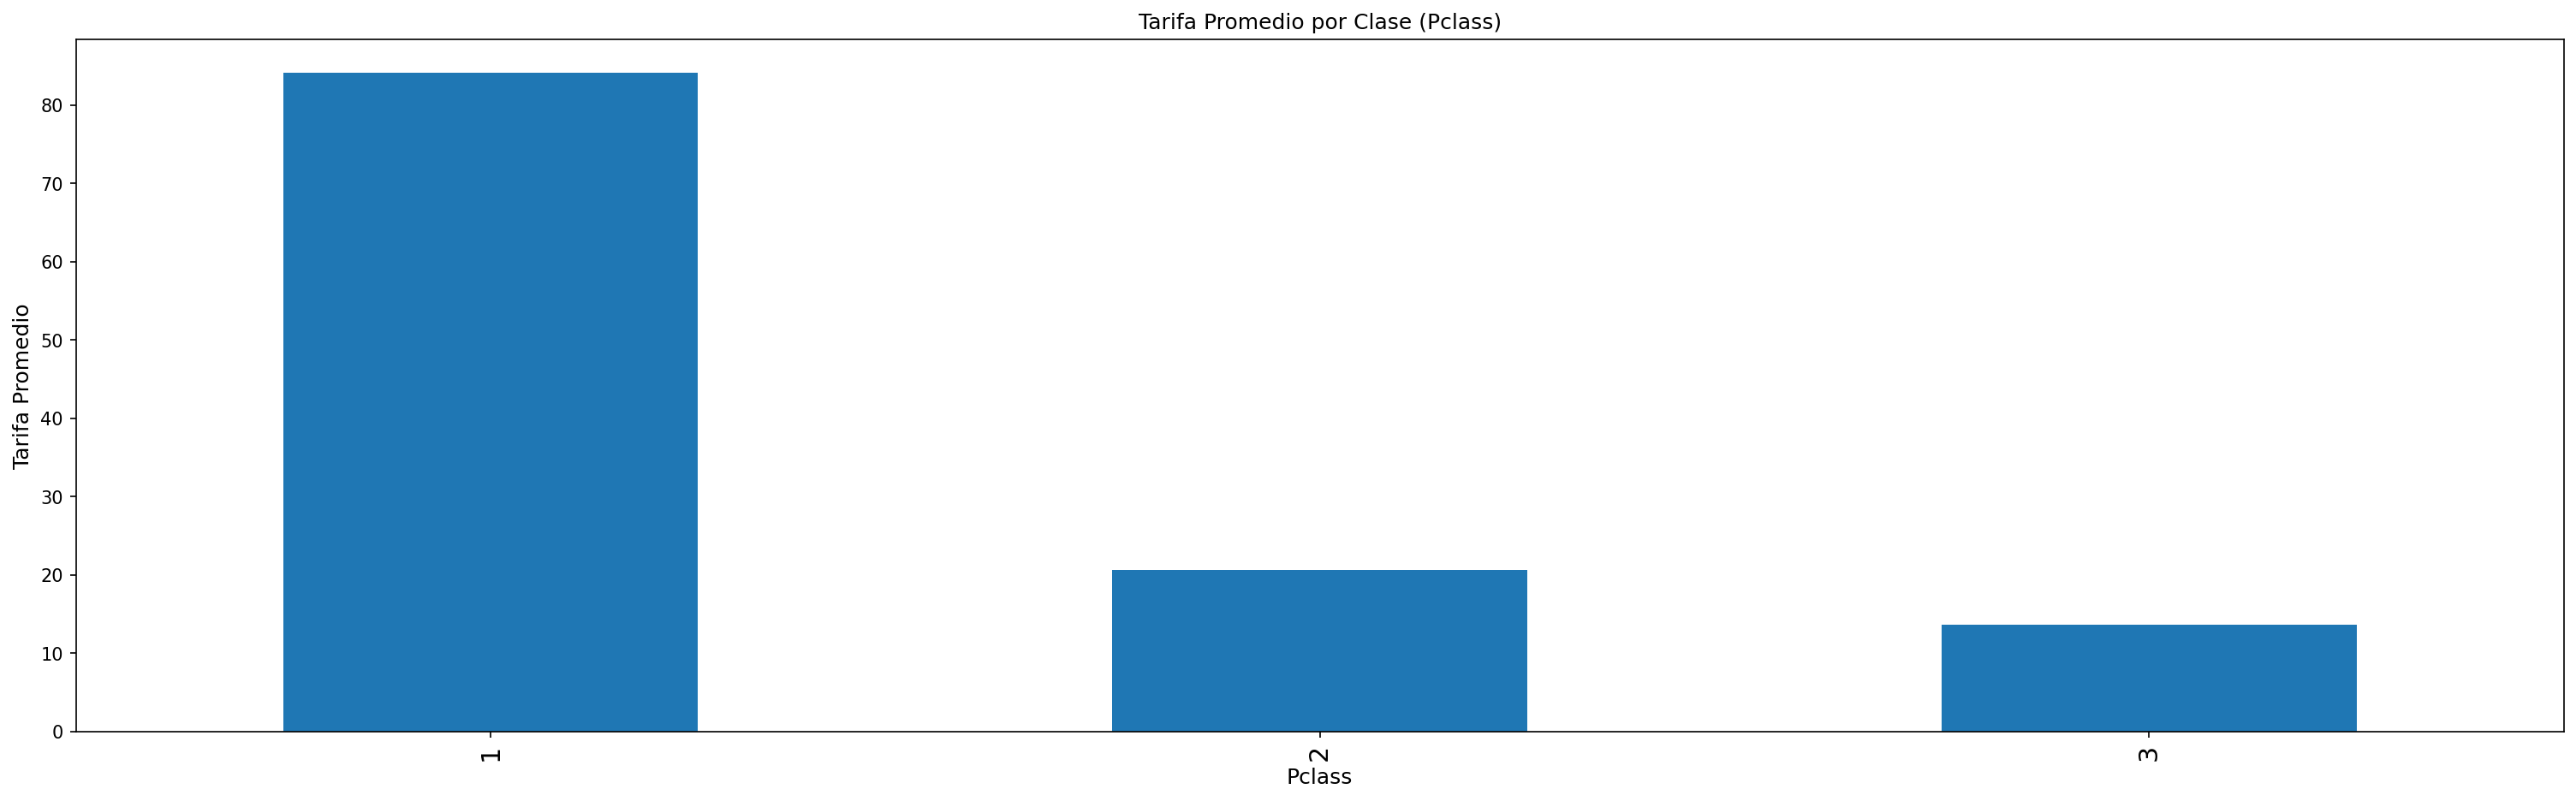

In [11]:
ax = plt.subplot()
ax.set_ylabel("Tarifa Promedio")
data.groupby("Pclass")["Fare"].mean().plot(kind="bar", figsize=(25, 7), ax=ax)
plt.title("Tarifa Promedio por Clase (Pclass)")

plt.show()

---

<a id='-feature-engineering'></a>
## 🔹 4: Feature Engineering (Ingeniería de Características)

En esta sección transformaremos los datos brutos en variables manejables y crearemos nuevas características basadas en el conocimiento del dominio.

### 📝 4.1 Combinación de Datasets

Unificamos los datos de entrenamiento y prueba para garantizar que todas las transformaciones sean uniformes y consistentes.

In [12]:
def get_combined_data():
    train = pd.read_csv("train.csv")
    test = pd.read_csv("test.csv")

    # Preservar targets
    targets = train.Survived
    train.drop(["Survived"], axis=1, inplace=True)

    # Combinar
    combined = pd.concat([train, test], ignore_index=True)
    combined.reset_index(inplace=True)
    combined.drop(["index", "PassengerId"], inplace=True, axis=1)

    return combined


combined = get_combined_data()
print(f"Dataset combinado creado. Dimensiones: {combined.shape}")

combined.sample(5)

Dataset combinado creado. Dimensiones: (1309, 10)


,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1046,3,"Duquemin, Mr. Joseph",male,24.0,0,0,S.O./P.P. 752,7.5500,NaN,S
495,3,"Yousseff, Mr. Gerious",male,NaN,0,0,2627,14.4583,NaN,C
1064,3,"Torfa, Mr. Assad",male,NaN,0,0,2673,7.2292,NaN,C
346,2,"Smith, Miss. Marion Elsie",female,40.0,0,0,31418,13.0000,NaN,S
540,1,"Crosby, Miss. Harriet R",female,36.0,0,2,WE/P 5735,71.0000,B22,S


### 📝 4.2 Procesamiento del Título

Extraemos el título de los nombres de los pasajeros para clasificar su estatus social.

In [13]:
Title_Dictionary = {
    "Capt": "Officer",
    "Col": "Officer",
    "Major": "Officer",
    "Jonkheer": "Royalty",
    "Don": "Royalty",
    "Sir": "Royalty",
    "Dr": "Officer",
    "Rev": "Officer",
    "the Countess": "Royalty",
    "Mme": "Mrs",
    "Mlle": "Miss",
    "Ms": "Mrs",
    "Mr": "Mr",
    "Mrs": "Mrs",
    "Miss": "Miss",
    "Master": "Master",
    "Lady": "Royalty",
}


def get_titles():
    # Extracción y mapeo
    combined["Title"] = combined["Name"].map(
        lambda name: name.split(",")[1].split(".")[0].strip()
    )
    combined["Title"] = combined.Title.map(Title_Dictionary)

    return combined


combined = get_titles()
print(f"Dataset combinado creado. Dimensiones: {combined.shape}")

combined.sample(5)

Dataset combinado creado. Dimensiones: (1309, 11)


,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
520,1,"Perreault, Miss. Anne",female,30.0,0,0,12749,93.5000,B73,S,Miss
916,3,"Robins, Mr. Alexander A",male,50.0,1,0,A/5. 3337,14.5000,NaN,S,Mr
233,3,"Asplund, Miss. Lillian Gertrud",female,5.0,4,2,347077,31.3875,NaN,S,Miss
857,1,"Daly, Mr. Peter Denis",male,51.0,0,0,113055,26.5500,E17,S,Mr
1177,3,"Franklin, Mr. Charles (Charles Fardon)",male,NaN,0,0,SOTON/O.Q. 3101314,7.2500,NaN,S,Mr


### 📝 4.3 Procesamiento de Edad (Imputación por Grupos)

Llenamos las edades faltantes utilizando la mediana calculada sobre grupos de Sexo, Clase y Título, evitando sesgos generales.

In [14]:
grouped_train = combined.iloc[:891].groupby(["Sex", "Pclass", "Title"])["Age"].median()
grouped_median_train = grouped_train.reset_index()[["Sex", "Pclass", "Title", "Age"]]


def fill_age(row):
    condition = (
        (grouped_median_train["Sex"] == row["Sex"])
        & (grouped_median_train["Title"] == row["Title"])
        & (grouped_median_train["Pclass"] == row["Pclass"])
    )
    return grouped_median_train[condition]["Age"].values[0]


def process_age():
    global combined
    combined["Age"] = combined.apply(
        lambda row: fill_age(row) if np.isnan(row["Age"]) else row["Age"], axis=1
    )
    return combined


combined = process_age()
print(f"Dataset combinado creado. Dimensiones: {combined.shape}")

combined.sample(5)

Dataset combinado creado. Dimensiones: (1309, 11)


,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
859,3,"Razi, Mr. Raihed",male,26.0,0,0,2629,7.2292,NaN,C,Mr
319,1,"Spedden, Mrs. Frederic Oakley (Margaretta Corn...",female,40.0,1,1,16966,134.5000,E34,C,Mrs
1197,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0,1,2,113781,151.5500,C22 C26,S,Mr
398,2,"Pain, Dr. Alfred",male,23.0,0,0,244278,10.5000,NaN,S,Officer
1250,3,"Lindell, Mrs. Edvard Bengtsson (Elin Gerda Per...",female,30.0,1,0,349910,15.5500,NaN,S,Mrs


### 📝 4.4 One-Hot Encoding para Títulos

Transformamos la columna categórica `Title` en variables binarias (dummies).

In [15]:
def process_names():
    global combined
    combined.drop("Name", axis=1, inplace=True)
    titles_dummies = pd.get_dummies(combined["Title"], prefix="Title").astype(int)
    combined = pd.concat([combined, titles_dummies], axis=1)
    combined.drop("Title", axis=1, inplace=True)
    return combined


combined = process_names()
print(f"Dataset combinado creado. Dimensiones: {combined.shape}")

combined.sample(5)

Dataset combinado creado. Dimensiones: (1309, 15)


,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Officer,Title_Royalty
173,3,male,21.0,0,0,STON/O 2. 3101280,7.925,NaN,S,0,0,1,0,0,0
47,3,female,18.0,0,0,14311,7.750,NaN,Q,0,1,0,0,0,0
850,3,male,4.0,4,2,347082,31.275,NaN,S,1,0,0,0,0,0
982,3,male,26.0,0,0,345498,7.775,NaN,S,0,0,1,0,0,0
115,3,male,21.0,0,0,STON/O 2. 3101294,7.925,NaN,S,0,0,1,0,0,0


### 📝 4.5 Procesamiento de Tarifas, Embarque y Cabinas

Realizamos imputaciones y codificaciones adicionales para las variables restantes.

In [16]:
def process_fares():
    global combined
    combined.Fare.fillna(combined.iloc[:891].Fare.mean(), inplace=True)
    return combined


combined = process_fares()
print(f"Dataset combinado creado. Dimensiones: {combined.shape}")

combined.sample(5)

Dataset combinado creado. Dimensiones: (1309, 15)


,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Officer,Title_Royalty
322,2,female,30.0,0,0,234818,12.3500,NaN,Q,0,1,0,0,0,0
648,3,male,26.0,0,0,S.O./P.P. 751,7.5500,NaN,S,0,0,1,0,0,0
381,3,female,1.0,0,2,2653,15.7417,NaN,C,0,1,0,0,0,0
895,3,female,22.0,1,1,3101298,12.2875,NaN,S,0,0,0,1,0,0
1281,1,male,23.0,0,0,12749,93.5000,B24,S,0,0,1,0,0,0


In [17]:
def process_embarked():
    global combined
    combined.Embarked.fillna("S", inplace=True)
    embarked_dummies = pd.get_dummies(combined["Embarked"], prefix="Embarked").astype(
        int
    )
    combined = pd.concat([combined, embarked_dummies], axis=1)
    combined.drop("Embarked", axis=1, inplace=True)
    return combined


combined = process_embarked()
print(f"Dataset combinado creado. Dimensiones: {combined.shape}")

combined.sample(5)

Dataset combinado creado. Dimensiones: (1309, 17)


,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Officer,Title_Royalty,Embarked_C,Embarked_Q,Embarked_S
963,3,female,29.0,0,0,3101297,7.9250,NaN,0,1,0,0,0,0,0,0,1
1046,3,male,24.0,0,0,S.O./P.P. 752,7.5500,NaN,0,0,1,0,0,0,0,0,1
885,3,female,39.0,0,5,382652,29.1250,NaN,0,0,0,1,0,0,0,1,0
1002,3,female,18.0,0,0,330968,7.7792,NaN,0,1,0,0,0,0,0,1,0
407,2,male,3.0,1,1,29106,18.7500,NaN,1,0,0,0,0,0,0,0,1


In [18]:
def process_cabin():
    global combined
    combined.Cabin.fillna("U", inplace=True)
    combined["Cabin"] = combined["Cabin"].map(lambda c: c[0])
    cabin_dummies = pd.get_dummies(combined["Cabin"], prefix="Cabin").astype(int)
    combined = pd.concat([combined, cabin_dummies], axis=1)
    combined.drop("Cabin", axis=1, inplace=True)
    return combined


combined = process_cabin()
print(f"Dataset combinado creado. Dimensiones: {combined.shape}")

combined.sample(5)

Dataset combinado creado. Dimensiones: (1309, 25)


,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Officer,Title_Royalty,Embarked_C,Embarked_Q,Embarked_S,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Cabin_U
1205,1,female,55.0,0,0,PC 17760,135.6333,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0
330,3,female,18.0,2,0,367226,23.2500,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1
1087,1,male,6.0,0,2,16966,134.5000,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
323,2,female,22.0,1,1,248738,29.0000,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1
205,3,female,2.0,0,1,347054,10.4625,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0


### 📝 4.6 Procesamiento de Tickets

Extraemos prefijos y manejamos los tickets numéricos puros como una categoría especial.

In [19]:
def cleanTicket(ticket):
    ticket = ticket.replace(".", "").replace("/", "").split()
    ticket = list(filter(lambda t: not t.isdigit(), map(lambda t: t.strip(), ticket)))
    return ticket[0] if len(ticket) > 0 else "XXX"


def process_ticket():
    global combined
    combined["Ticket"] = combined["Ticket"].map(cleanTicket)
    tickets_dummies = pd.get_dummies(combined["Ticket"], prefix="Ticket").astype(int)
    combined = pd.concat([combined, tickets_dummies], axis=1)
    combined.drop("Ticket", inplace=True, axis=1)
    return combined


combined = process_ticket()
print(f"Dataset combinado creado. Dimensiones: {combined.shape}")

combined.sample(5)

Dataset combinado creado. Dimensiones: (1309, 61)


,Pclass,Sex,Age,SibSp,Parch,Fare,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Officer,Title_Royalty,Embarked_C,Embarked_Q,Embarked_S,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Cabin_U,Ticket_A,Ticket_A4,Ticket_A5,Ticket_AQ3,Ticket_AQ4,Ticket_AS,Ticket_C,Ticket_CA,Ticket_CASOTON,Ticket_FC,Ticket_FCC,Ticket_Fa,Ticket_LINE,Ticket_LP,Ticket_PC,Ticket_PP,Ticket_PPP,Ticket_SC,Ticket_SCA3,Ticket_SCA4,Ticket_SCAH,Ticket_SCOW,Ticket_SCPARIS,Ticket_SCParis,Ticket_SOC,Ticket_SOP,Ticket_SOPP,Ticket_SOTONO2,Ticket_SOTONOQ,Ticket_SP,Ticket_STONO,Ticket_STONO2,Ticket_STONOQ,Ticket_SWPP,Ticket_WC,Ticket_WEP,Ticket_XXX
1238,3,female,38.0,0,0,7.2292,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
767,3,female,30.5,0,0,7.7500,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
186,3,female,31.0,1,0,15.5000,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
546,2,female,19.0,1,0,26.0000,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
372,3,male,19.0,0,0,8.0500,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


### 📝 4.7 Variables de Familia y Grupos de Edad

Generamos variables que resumen el tamaño del núcleo familiar y simplifican el rango etario.

In [20]:
def process_family():
    global combined
    combined["FamilySize"] = combined["Parch"] + combined["SibSp"] + 1
    combined["Singleton"] = combined["FamilySize"].map(lambda s: 1 if s == 1 else 0)
    combined["SmallFamily"] = combined["FamilySize"].map(
        lambda s: 1 if 2 <= s <= 4 else 0
    )
    combined["LargeFamily"] = combined["FamilySize"].map(lambda s: 1 if 5 <= s else 0)
    return combined


combined = process_family()
print(f"Dataset combinado creado. Dimensiones: {combined.shape}")

combined.sample(5)

Dataset combinado creado. Dimensiones: (1309, 65)


,Pclass,Sex,Age,SibSp,Parch,Fare,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Officer,Title_Royalty,Embarked_C,Embarked_Q,Embarked_S,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Cabin_U,Ticket_A,Ticket_A4,Ticket_A5,Ticket_AQ3,Ticket_AQ4,Ticket_AS,Ticket_C,Ticket_CA,Ticket_CASOTON,Ticket_FC,Ticket_FCC,Ticket_Fa,Ticket_LINE,Ticket_LP,Ticket_PC,Ticket_PP,Ticket_PPP,Ticket_SC,Ticket_SCA3,Ticket_SCA4,Ticket_SCAH,Ticket_SCOW,Ticket_SCPARIS,Ticket_SCParis,Ticket_SOC,Ticket_SOP,Ticket_SOPP,Ticket_SOTONO2,Ticket_SOTONOQ,Ticket_SP,Ticket_STONO,Ticket_STONO2,Ticket_STONOQ,Ticket_SWPP,Ticket_WC,Ticket_WEP,Ticket_XXX,FamilySize,Singleton,SmallFamily,LargeFamily
838,3,male,32.0,0,0,56.4958,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0
587,1,male,60.0,1,1,79.2000,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,3,0,1,0
784,3,male,25.0,0,0,7.0500,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0
524,3,male,26.0,0,0,7.2292,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0
283,3,male,19.0,0,0,8.0500,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0


In [21]:
def process_age_groups():
    global combined
    combined["Younger"] = (combined["Age"] < 20).astype(int)
    combined["Adult"] = ((combined["Age"] >= 20) & (combined["Age"] <= 40)).astype(int)
    combined["Elder"] = (combined["Age"] > 40).astype(int)
    return combined


combined = process_age_groups()
print(f"Dataset combinado creado. Dimensiones: {combined.shape}")

combined.sample(5)

Dataset combinado creado. Dimensiones: (1309, 68)


,Pclass,Sex,Age,SibSp,Parch,Fare,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Officer,Title_Royalty,Embarked_C,Embarked_Q,Embarked_S,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Cabin_U,Ticket_A,Ticket_A4,Ticket_A5,Ticket_AQ3,Ticket_AQ4,Ticket_AS,Ticket_C,Ticket_CA,Ticket_CASOTON,Ticket_FC,Ticket_FCC,Ticket_Fa,Ticket_LINE,Ticket_LP,Ticket_PC,Ticket_PP,Ticket_PPP,Ticket_SC,Ticket_SCA3,Ticket_SCA4,Ticket_SCAH,Ticket_SCOW,Ticket_SCPARIS,Ticket_SCParis,Ticket_SOC,Ticket_SOP,Ticket_SOPP,Ticket_SOTONO2,Ticket_SOTONOQ,Ticket_SP,Ticket_STONO,Ticket_STONO2,Ticket_STONOQ,Ticket_SWPP,Ticket_WC,Ticket_WEP,Ticket_XXX,FamilySize,Singleton,SmallFamily,LargeFamily,Younger,Adult,Elder
233,3,female,5.0,4,2,31.3875,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,7,0,0,1,1,0,0
1114,3,male,21.0,0,0,7.7958,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,1,0
1111,2,female,30.0,1,0,13.8583,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,1,0
650,3,male,26.0,0,0,7.8958,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,1,0
700,1,female,18.0,1,0,227.5250,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,1,0,0


---

<a id='-sklearn'></a>
## 🔹 5: Preprocesamiento con Scikit-Learn

En esta sección final, aplicaremos codificación numérica profesional para las variables categóricas restantes.

### 📝 5.1 Codificación de Sexo con LabelEncoder

Para asegurar un flujo de datos limpio y uniforme, utilizamos `LabelEncoder` para transformar el Sexo y la Clase del Pasajero (Pclass) en valores numéricos. 

**Mantenimiento de Consistencia:** Siguiendo las directrices profesionales, se ha sustituido el método de dummies para Pclass por una codificación basada en Scikit-Learn.

In [22]:
def process_scikit_label_encoding():
    global combined
    le = LabelEncoder()
    # Codificación de Sexo
    combined["Sex"] = le.fit_transform(combined["Sex"])
    return combined


combined = process_scikit_label_encoding()
print(f"Dataset combinado creado. Dimensiones: {combined.shape}")

combined.sample(5)

Dataset combinado creado. Dimensiones: (1309, 68)


,Pclass,Sex,Age,SibSp,Parch,Fare,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Officer,Title_Royalty,Embarked_C,Embarked_Q,Embarked_S,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Cabin_U,Ticket_A,Ticket_A4,Ticket_A5,Ticket_AQ3,Ticket_AQ4,Ticket_AS,Ticket_C,Ticket_CA,Ticket_CASOTON,Ticket_FC,Ticket_FCC,Ticket_Fa,Ticket_LINE,Ticket_LP,Ticket_PC,Ticket_PP,Ticket_PPP,Ticket_SC,Ticket_SCA3,Ticket_SCA4,Ticket_SCAH,Ticket_SCOW,Ticket_SCPARIS,Ticket_SCParis,Ticket_SOC,Ticket_SOP,Ticket_SOPP,Ticket_SOTONO2,Ticket_SOTONOQ,Ticket_SP,Ticket_STONO,Ticket_STONO2,Ticket_STONOQ,Ticket_SWPP,Ticket_WC,Ticket_WEP,Ticket_XXX,FamilySize,Singleton,SmallFamily,LargeFamily,Younger,Adult,Elder
685,2,1,25.0,1,2,41.5792,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,1,0,0,1,0
559,3,0,36.0,1,0,17.4000,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,1,0,0,1,0
513,1,0,54.0,1,0,59.4000,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0,1
654,3,0,18.0,0,0,6.7500,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,0,0
84,2,0,17.0,0,0,10.5000,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0


<a id='-sklearn'></a>
## 🔹 6: Modeling and Prediction

En esta fase final, implementaremos un pipeline de aprendizaje automático para predecir la supervivencia de los pasajeros. El proceso abarca desde la preparación de los conjuntos de datos hasta la selección de las variables más influyentes y la evaluación de múltiples algoritmos para identificar el modelo con mayor capacidad predictiva.

### 📝 6.1 Preparación de Herramientas y Datos

Comenzamos importando los módulos necesarios de Scikit-Learn. Utilizaremos clasificadores populares, herramientas para la validación cruzada y utilidades para la selección de características.

In [23]:
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, SelectFromModel
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Definimos una función para recuperar los conjuntos de entrenamiento y prueba a partir del dataframe `combined`. Es crucial separar nuevamente los datos para evitar que el modelo 'conozca' las etiquetas del conjunto de prueba durante el entrenamiento (*Data Leakage*).

In [24]:
def recover_train_test_target():
    global combined
    targets = pd.read_csv("train.csv", usecols=["Survived"])["Survived"].values
    train = combined.iloc[:891]
    test = combined.iloc[891:]
    return train, test, targets

In [25]:
train, test, targets = recover_train_test_target()

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Targets:", len(targets))

Train shape: (891, 68)
Test shape: (418, 68)
Targets: 891


### 📝 6.2 Evaluación de Relevancia (Feature Importance)

El primer paso técnico es evaluar la importancia de cada característica. Utilizamos un modelo de Bosque Aleatorio (`RandomForestClassifier`) debido a su capacidad intrínseca para cuantificar cuánto contribuye cada variable a la reducción de la impureza en los nodos de decisión. Graficar la importancia nos permite visualizar qué factores (como la edad, el sexo o la tarifa) son realmente determinantes en la predicción.

<Figure size 3000x3000 with 0 Axes>

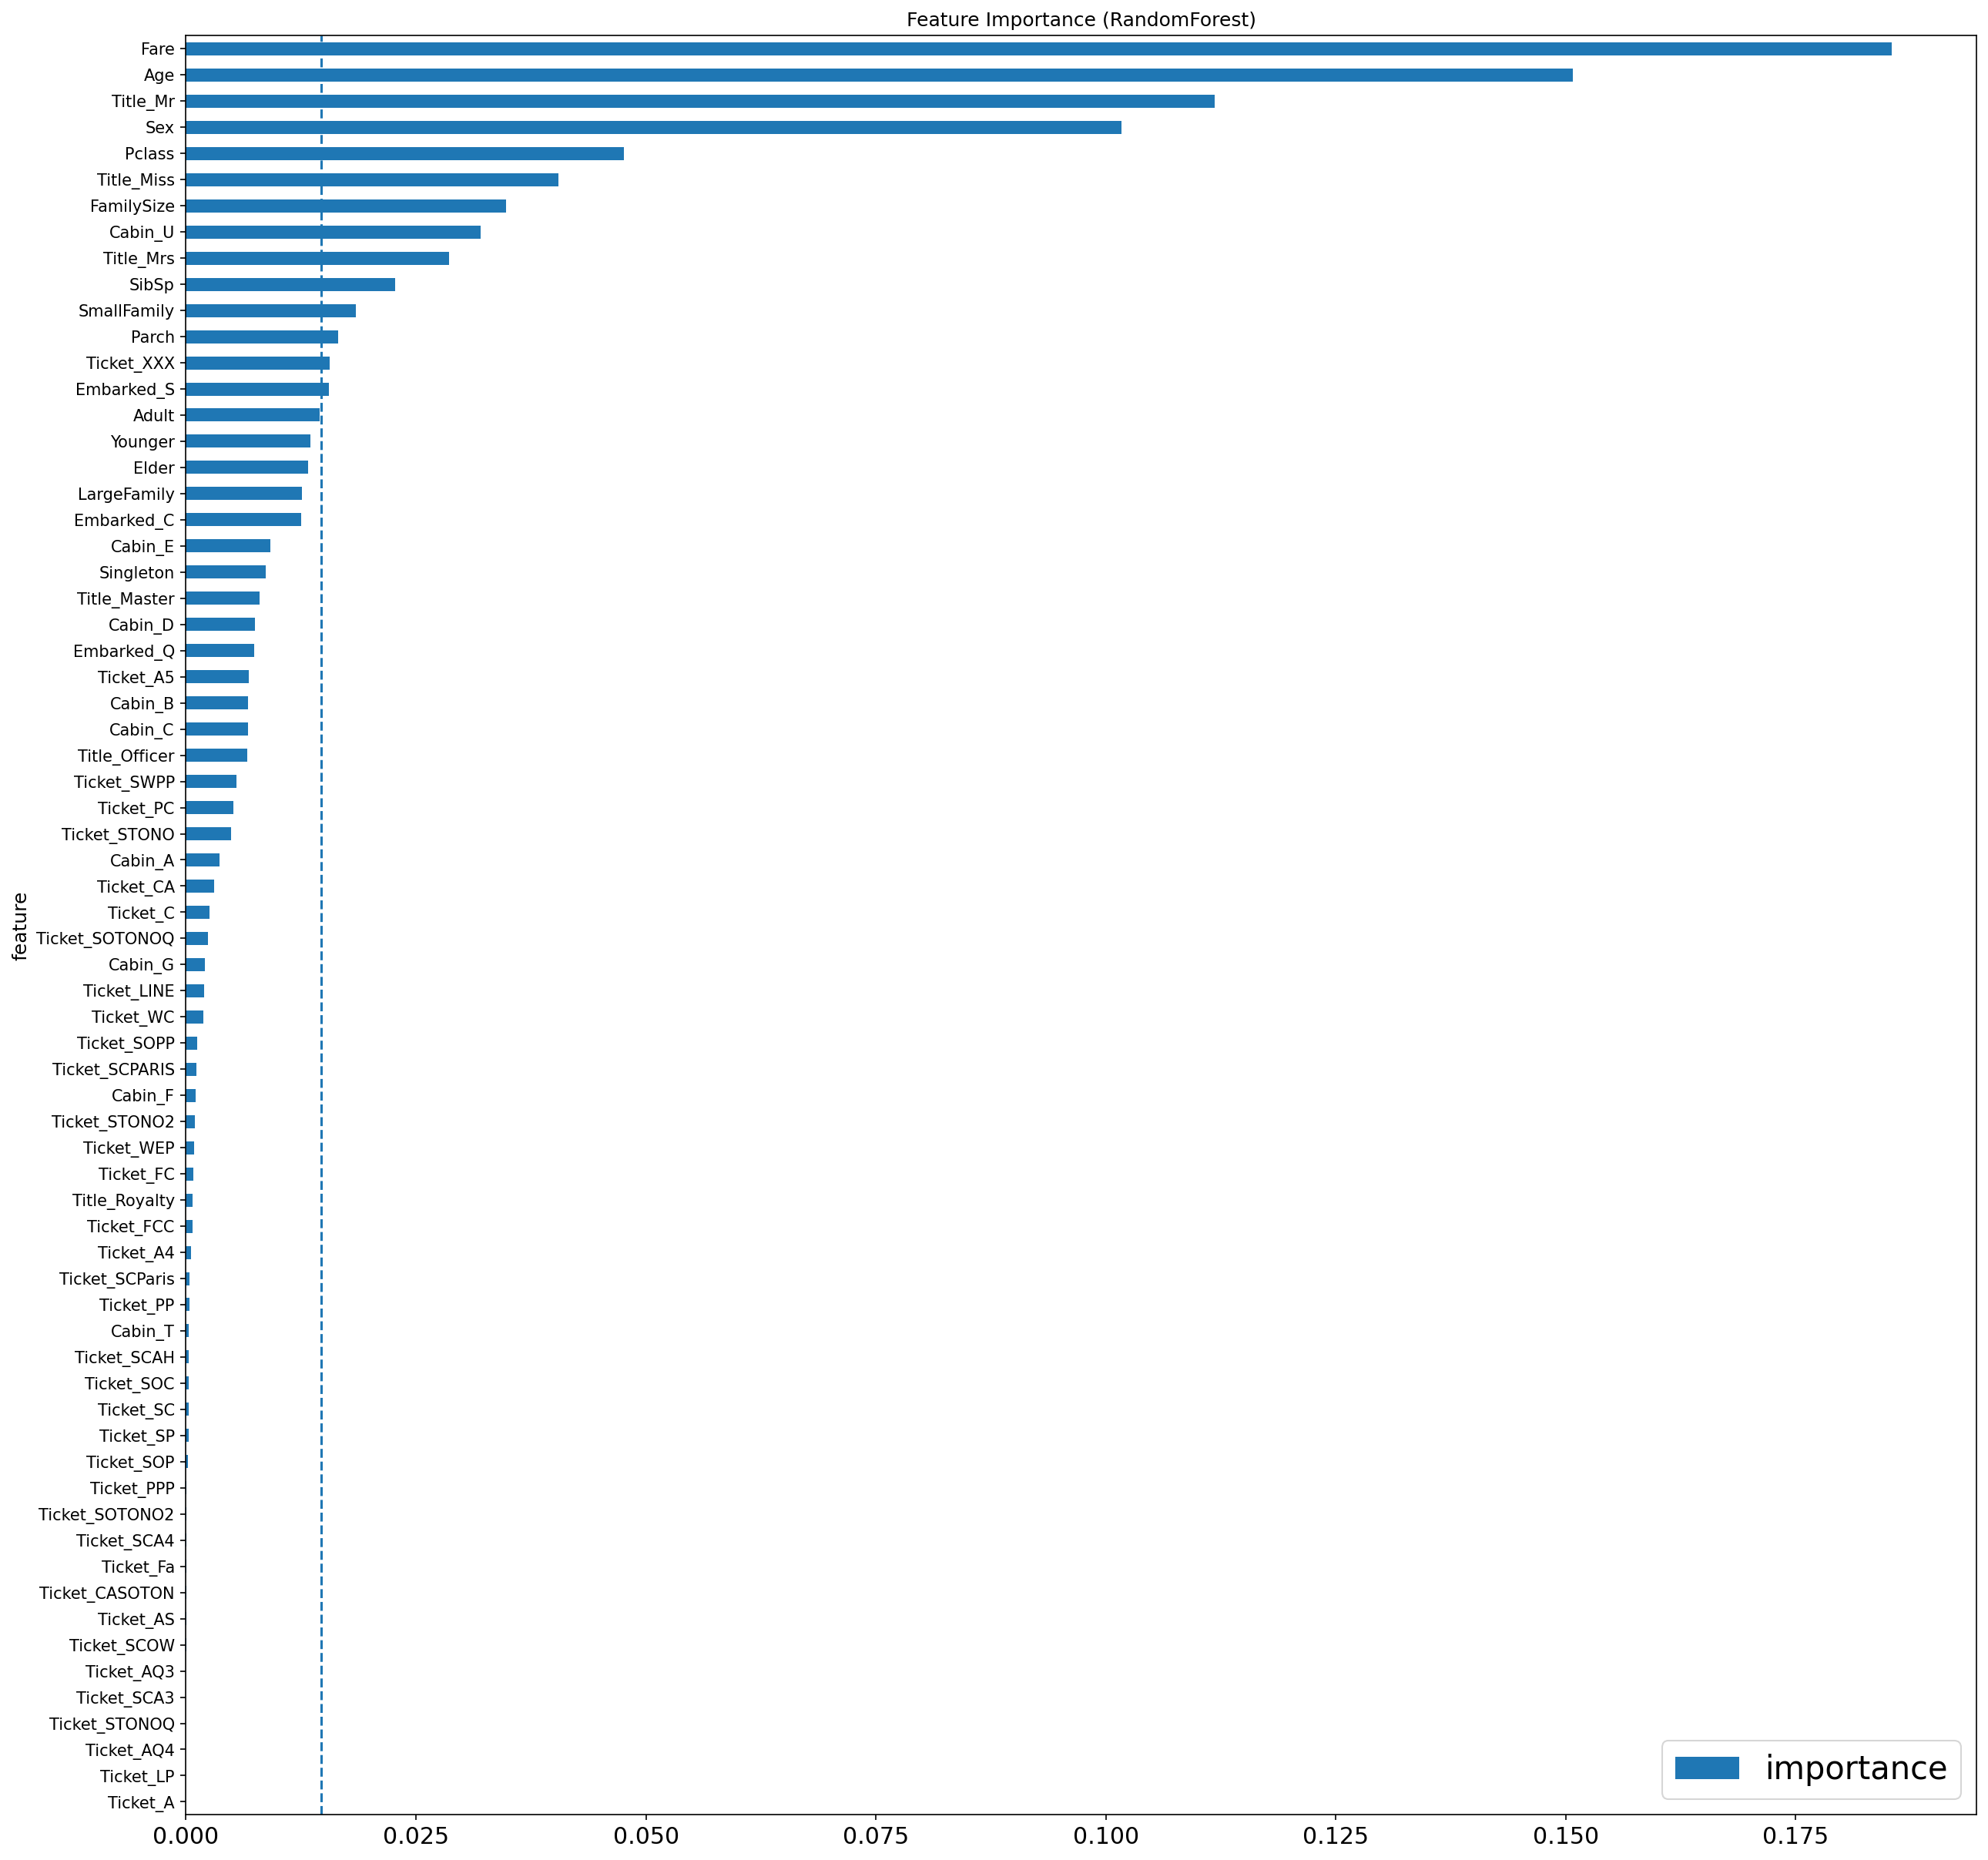

In [26]:
clf = RandomForestClassifier(n_estimators=50, max_features="sqrt", random_state=42)

clf.fit(train, targets)

features = pd.DataFrame()
features["feature"] = train.columns
features["importance"] = clf.feature_importances_
features.sort_values(by=["importance"], ascending=True, inplace=True)
features.set_index("feature", inplace=True)

plt.figure(figsize=(20, 20))
features.plot(kind="barh", figsize=(20, 20))

# línea indicando la media de importancia
mean_imp = features["importance"].mean()
plt.axvline(mean_imp, linestyle="--")
plt.title("Feature Importance (RandomForest)")
plt.show()

Basándonos en el análisis anterior, realizamos una reducción de dimensionalidad utilizando `SelectFromModel`. Al conservar solo aquellas características cuya importancia es superior al promedio, eliminamos el ruido y mejoramos tanto la eficiencia computacional como la capacidad de generalización del modelo.

In [27]:
model = SelectFromModel(clf, prefit=True)

train_reduced = model.transform(train)
test_reduced = model.transform(test)

print("Train reduced:", train_reduced.shape)
print("Test reduced:", test_reduced.shape)

Train reduced: (891, 14)
Test reduced: (418, 14)


### 📝 6.3 Comparación de Modelos y Validación Cruzada

Para encontrar el algoritmo más robusto, comparamos cuatro modelos distintos: Regresión Logística (estándar y con validación cruzada interna), Bosque Aleatorio y Gradient Boosting. Aplicamos validación cruzada de 5 pliegues para obtener una estimación del *accuracy* que sea estadísticamente significativa y menos dependiente de una partición específica de los datos.

In [28]:
def compute_score(clf, X, y, scoring="accuracy"):
    xval = cross_val_score(clf, X, y, cv=5, scoring=scoring)
    return np.mean(xval)


logreg = LogisticRegression(max_iter=500)
logreg_cv = LogisticRegressionCV(max_iter=500)
rf = RandomForestClassifier()
gboost = GradientBoostingClassifier()

models = [
    ("LogisticRegression", logreg),
    ("LogisticRegressionCV", logreg_cv),
    ("RandomForest", rf),
    ("GradientBoosting", gboost),
]

results = {}

for name, model in models:
    print("Cross-validation of:", name)
    score = compute_score(model, X=train_reduced, y=targets, scoring="accuracy")
    results[name] = score
    print("CV score =", score)
    print("************")

results

Cross-validation of: LogisticRegression
CV score = 0.8148013307388112
************
Cross-validation of: LogisticRegressionCV
CV score = 0.8114493754315486
************
Cross-validation of: RandomForest
CV score = 0.8080660347749671
************
Cross-validation of: GradientBoosting
CV score = 0.8327663046889711
************


{'LogisticRegression': np.float64(0.8148013307388112),
 'LogisticRegressionCV': np.float64(0.8114493754315486),
 'RandomForest': np.float64(0.8080660347749671),
 'GradientBoosting': np.float64(0.8327663046889711)}

Una vez obtenidos los resultados, seleccionamos el modelo con el mejor desempeño promedio. Generalmente, algoritmos de ensamble como `GradientBoostingClassifier` tienden a ofrecer resultados superiores en este tipo de datasets tabulares competitivos.

In [29]:
best_model_name = max(results, key=results.get)
best_model_score = results[best_model_name]

print("Best model:", best_model_name)
print("Score:", best_model_score)

# entrenar el mejor modelo con todos los datos
if best_model_name == "GradientBoosting":
    best_model = GradientBoostingClassifier()
elif best_model_name == "RandomForest":
    best_model = RandomForestClassifier()
elif best_model_name == "LogisticRegression":
    best_model = LogisticRegression(max_iter=500)
else:
    best_model = LogisticRegressionCV(max_iter=500)

best_model.fit(train_reduced, targets)

Best model: GradientBoosting
Score: 0.8327663046889711


GradientBoostingClassifier()

### 📝 6.4 Implementación de la Función de Predicción

Encapsulamos la lógica de inferencia en una función personalizada. Esta función se encarga de transformar los datos de entrada de un nuevo pasajero al mismo formato exacto (columnas, orden y codificación) que el modelo espera, asegurando la consistencia entre el entrenamiento y la aplicación práctica.

In [30]:
def predict_person(model, model_selector, **kwargs):
    """
    Recibe los datos de un pasajero (kwargs), los transforma al mismo
    formato que el dataframe 'train' y aplica el modelo.
    """
    global combined  # solo esto, nada más

    # convertir a DataFrame temporal
    df = pd.DataFrame([kwargs])

    # asegurar que existan todas las columnas del training
    for col in train.columns:
        if col not in df.columns:
            df[col] = 0

    # reordenar columnas para que coincidan con el training
    df = df[train.columns]

    # reducir features con el mismo selector usado en train
    df_reduced = model_selector.transform(df)

    # predecir
    prediction = model.predict(df_reduced)[0]
    return prediction

In [31]:
model_selector = SelectFromModel(clf, prefit=True)

Probamos nuestro sistema con un caso hipotético para validar que el pipeline completo, desde el preprocesamiento de las variables hasta la decisión del modelo, funciona correctamente.

In [32]:
jorge = predict_person(
    model=best_model,
    model_selector=model_selector,
    Pclass=2,
    Sex_male=1,
    Sex_female=0,
    Age=35,
    SibSp=0,
    Parch=0,
    Fare=20,
    Embarked_S=1,
    Embarked_C=0,
    Embarked_Q=0,
    Title_Mr=1,
)

print("¿Jorge sobreviviría?:", "Sí" if jorge == 1 else "No")

¿Jorge sobreviviría?: Sí
